# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("delivery_dataset.csv")
df

,Дата заказа (ГГГГ-ММ-ДД),Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах)
0,2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2
1,2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6
2,2026-08-15,ORD-202608003,2.2,1,3,20.0,5,16.3
3,2026-08-08,ORD-202608004,0.9,2,6,22.9,1,15.8
4,2026-08-21,ORD-202608005,12.3,14,4,18.1,2,69.2
...,...,...,...,...,...,...,...,...
495,2026-08-12,ORD-202608496,5.2,2,3,18.0,9,28.9
496,2026-08-09,ORD-202608497,10.0,3,4,21.6,10,48.0
497,2026-08-07,ORD-202608498,5.5,3,2,9.5,3,27.0
498,2026-08-28,ORD-202608499,7.1,6,4,13.5,1,40.4


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих;
* в тестовой: 100 последних.

In [2]:
features = [
    "Расстояние до клиента (в км)",
    "Количество позиций в чеке (в шт.)",
    "Балл пробок на дорогах (в баллах)",
    "Погода (в градусах Цельсия)",
    "Этаж доставки (в этажах)"
]
target = "Время доставки (в минутах)"

train = df.iloc[:300]
val = df.iloc[300:400]
test = df.iloc[400:500]

X_train = train[features].to_numpy(dtype=float)
y_train = train[target].to_numpy(dtype=float)
X_val = val[features].to_numpy(dtype=float)
y_val = val[target].to_numpy(dtype=float)
X_test = test[features].to_numpy(dtype=float)
y_test = test[target].to_numpy(dtype=float)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (300, 5)
Val: (100, 5)
Test: (100, 5)


#### Вопрос 1.

Для чего мы разбиваем данные на выборки? Для чего нам нужна тренировачная, для чего валидационная, для чего тестовая?

**Ответ:** тренировочная выборка нужна для обучения модели, валидационная — чтобы проверить её во время обучения, а тестовая — для итоговой проверки на новых данных.

#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [3]:
!pip install scikit-learn

#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [4]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=0.0, solver="sparse_cg")
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
val_pred = model.predict(X_val)

train_sse = np.sum((y_train - train_pred) ** 2)
val_sse = np.sum((y_val - val_pred) ** 2)

print("Train SSE:", train_sse)
print("Val SSE:", val_sse)

Train SSE: 5529.134405829647
Val SSE: 2078.5052447961225


#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

Итераций: 7
Train RMSE: 4.29306976642963
Val RMSE: 4.559062672081019


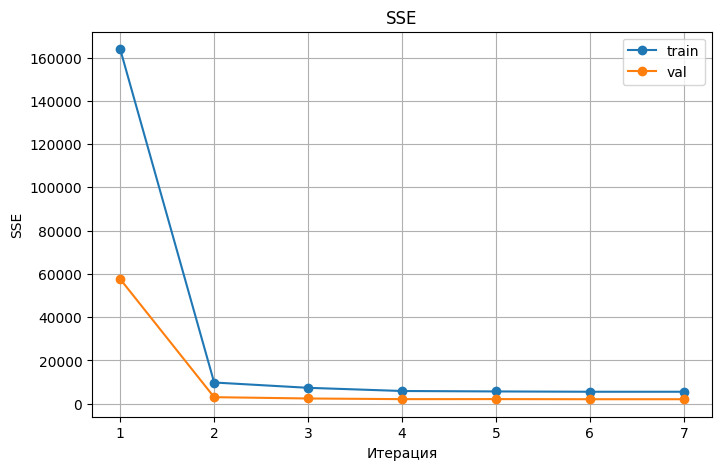

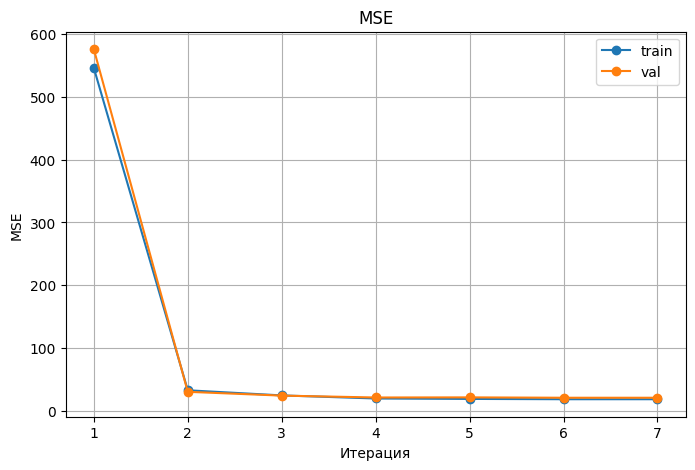

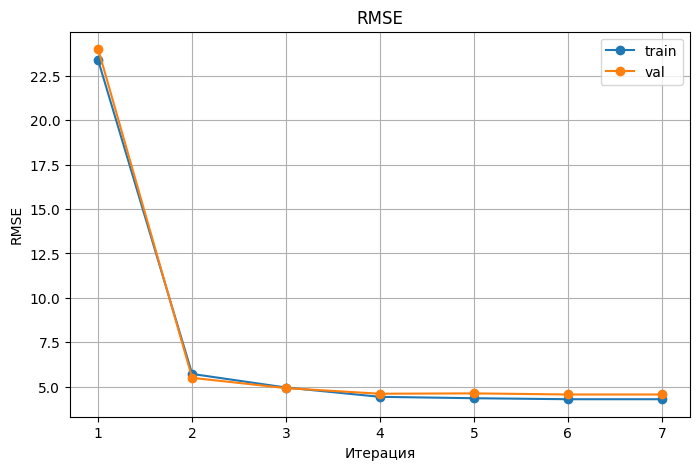

In [5]:
epsilon = 1e-8
max_iter = 100

X_train_cg = np.column_stack((np.ones(len(X_train)), X_train))
X_val_cg = np.column_stack((np.ones(len(X_val)), X_val))

A = X_train_cg.T @ X_train_cg
b = X_train_cg.T @ y_train

w = np.zeros(X_train_cg.shape[1])
r = b - A @ w
p = r.copy()

train_sse_history = []
val_sse_history = []
train_mse_history = []
val_mse_history = []
train_rmse_history = []
val_rmse_history = []

for _ in range(max_iter):
    Ap = A @ p
    alpha = (r @ r) / (p @ Ap)
    w = w + alpha * p
    r_new = r - alpha * Ap

    train_iter = X_train_cg @ w
    val_iter = X_val_cg @ w

    train_sse = np.sum((y_train - train_iter) ** 2)
    val_sse = np.sum((y_val - val_iter) ** 2)
    train_mse = train_sse / len(y_train)
    val_mse = val_sse / len(y_val)

    train_sse_history.append(train_sse)
    val_sse_history.append(val_sse)
    train_mse_history.append(train_mse)
    val_mse_history.append(val_mse)
    train_rmse_history.append(np.sqrt(train_mse))
    val_rmse_history.append(np.sqrt(val_mse))

    if np.linalg.norm(r_new) < epsilon:
        break

    beta = (r_new @ r_new) / (r @ r)
    p = r_new + beta * p
    r = r_new

iterations = range(1, len(train_sse_history) + 1)

print("Итераций:", len(train_sse_history))
print("Train RMSE:", train_rmse_history[-1])
print("Val RMSE:", val_rmse_history[-1])

plt.figure(figsize=(8, 5))
plt.plot(iterations, train_sse_history, marker="o", label="train")
plt.plot(iterations, val_sse_history, marker="o", label="val")
plt.xlabel("Итерация")
plt.ylabel("SSE")
plt.title("SSE")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(iterations, train_mse_history, marker="o", label="train")
plt.plot(iterations, val_mse_history, marker="o", label="val")
plt.xlabel("Итерация")
plt.ylabel("MSE")
plt.title("MSE")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(iterations, train_rmse_history, marker="o", label="train")
plt.plot(iterations, val_rmse_history, marker="o", label="val")
plt.xlabel("Итерация")
plt.ylabel("RMSE")
plt.title("RMSE")
plt.grid()
plt.legend()
plt.show()

#### Вопрос 2.

Какую информацию про нашу модель несут эти графики?

**Ответ:** по графикам видно, как меняется ошибка модели и не начинает ли она переобучаться.

#### Вопрос 3.

Какая траектория линий train и val ошибок будет на графиках недообученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках обученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках переобученной модели и почему?

**Ответ:** у недообученной модели ошибки train и val остаются высокими. У нормально обученной обе ошибки уменьшаются и остаются примерно рядом. При переобучении ошибка train падает, а val начинает расти.

#### Шаг 6. Применение модели на тестовой выборке

In [6]:
y_predict = model.predict(X_test)

result = pd.DataFrame({
    "ID заказа": test["Шифр заказа (ID)"].to_numpy(),
    "Предсказанное время": y_predict,
    "Реальное время": y_test,
    "Разница": y_predict - y_test
})

result.to_csv("delivery_predictions.csv", index=False)
result

,ID заказа,Предсказанное время,Реальное время,Разница
0,ORD-202608401,33.066235,33.9,-0.833765
1,ORD-202608402,33.125508,33.1,0.025508
2,ORD-202608403,20.852183,16.3,4.552183
3,ORD-202608404,34.385205,34.7,-0.314795
4,ORD-202608405,17.562288,13.3,4.262288
...,...,...,...,...
95,ORD-202608496,30.261688,28.9,1.361688
96,ORD-202608497,54.525097,48.0,6.525097
97,ORD-202608498,28.605027,27.0,1.605027
98,ORD-202608499,41.576744,40.4,1.176744


#### Шаг 7. RMSE на тестовой выборке

In [7]:
test_rmse = np.sqrt(np.mean((y_test - y_predict) ** 2))
print("Test RMSE:", test_rmse)

Test RMSE: 4.831131903177555


#### Вопрос 4.

Что получившийся RMSE может сказать о нашей модели?

**Ответ:** RMSE показывает, насколько сильно модель в среднем ошибается в прогнозе. Получилось около **4,8 минуты**, результат выглядит нормальным.